In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['bruehler_straße'].sum())
header = 'bruehler_straße'

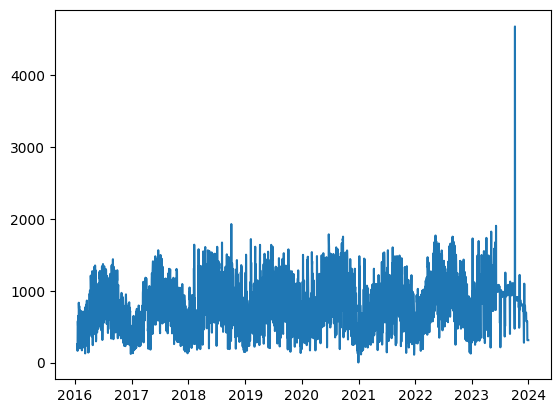

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

In [4]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [5]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [6]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,8304,14704,16553,25046,26992,27757,29613,29314,31948,21358,19176,16633
2017,13990,14895,23436,23016,29670,31631,29711,27433,26836,26335,22038,15630
2018,18982,17830,21279,30568,30740,32520,30581,29346,29167,28013,26622,20105
2019,19550,23804,23838,25277,31068,31052,29302,29941,28028,27837,25136,20663
2020,23090,20993,24808,26740,31517,33161,34343,33103,34081,29783,25448,18676
2021,18347,20443,20701,24330,22443,27680,25790,29228,31462,25436,22948,20303
2022,19611,18930,30647,27402,38110,33049,30694,39589,32882,30313,29584,18052
2023,21723,23781,30237,28850,33095,30851,27825,29346,29189,31000,24128,18089


Monatlich


In [7]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     17949.625
2     19422.500
3     23937.375
4     26403.625
5     30454.375
6     30962.625
7     29732.375
8     30912.500
9     30449.125
10    27509.375
11    24385.000
12    18518.875
Name: bruehler_straße, dtype: float64


In [8]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [9]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [10]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,bruehler_straße
year-month,,
2016-01-01,2016-01-01,8304
2016-02-01,2016-02-01,14704
2016-03-01,2016-03-01,16553
2016-04-01,2016-04-01,25046
2016-05-01,2016-05-01,26992
...,...,...
2023-08-01,2023-08-01,29346
2023-09-01,2023-09-01,29189
2023-10-01,2023-10-01,31000


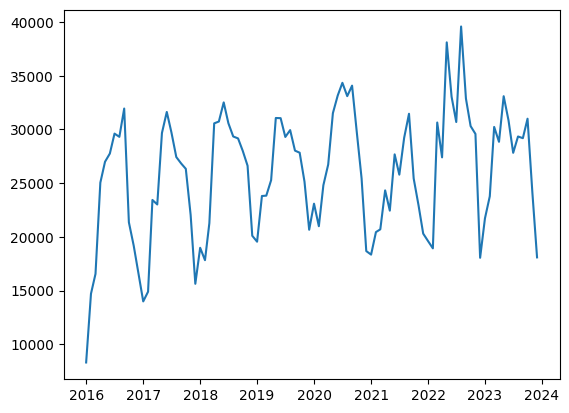

In [11]:
plt.plot(df_month[header])

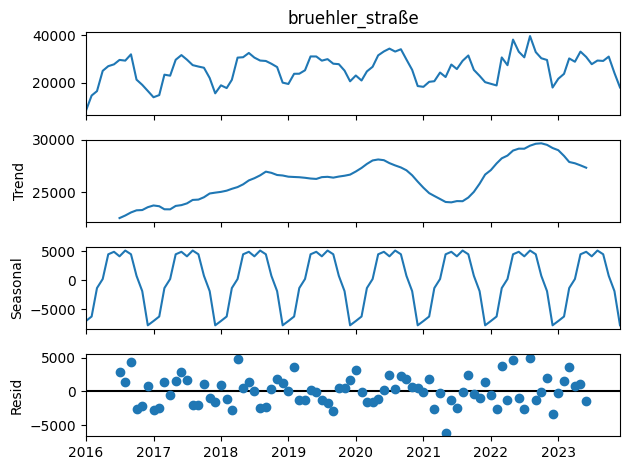

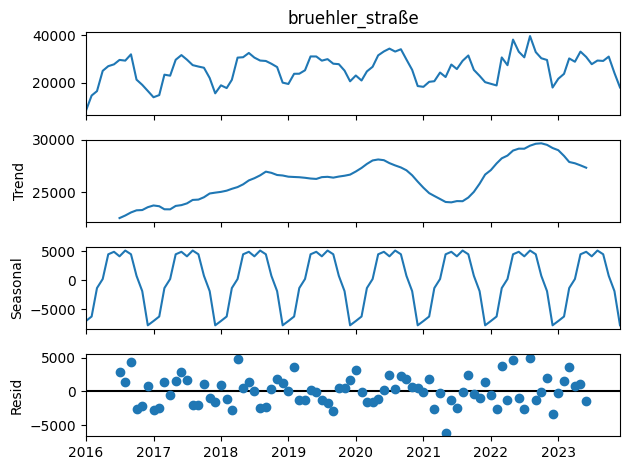

In [12]:
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [13]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -2.1009
p-value = 0.2441


In [14]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,bruehler_straße,scaled,log
year-month,,,,
2016-01-01,2016-01-01,8304,1.000000,0.000000
2016-02-01,2016-02-01,14704,8099.552022,8.999564
2016-03-01,2016-03-01,16553,10439.274317,9.253330
2016-04-01,2016-04-01,25046,21186.305929,9.961110
2016-05-01,2016-05-01,26992,23648.771903,10.071066
...,...,...,...,...
2023-08-01,2023-08-01,29346,26627.520569,10.189701
2023-09-01,2023-09-01,29189,26428.852965,10.182212
2023-10-01,2023-10-01,31000,28720.490107,10.265366


In [15]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [16]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -2.1644
P-value = 0.2194


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13292\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


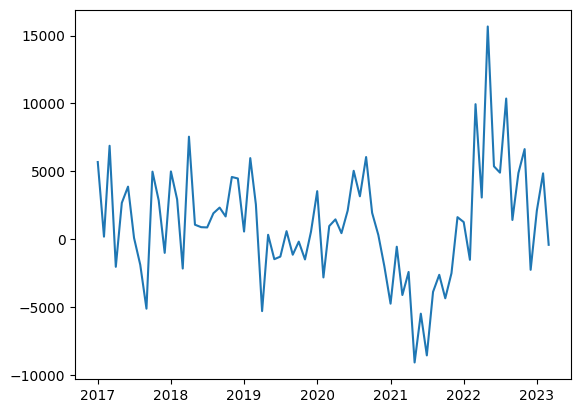

In [17]:
plt.plot(df_train['differences'])

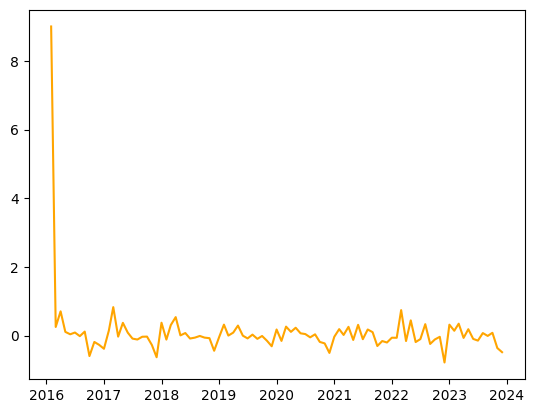

In [18]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [19]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -3.8267
P-value = 0.0026


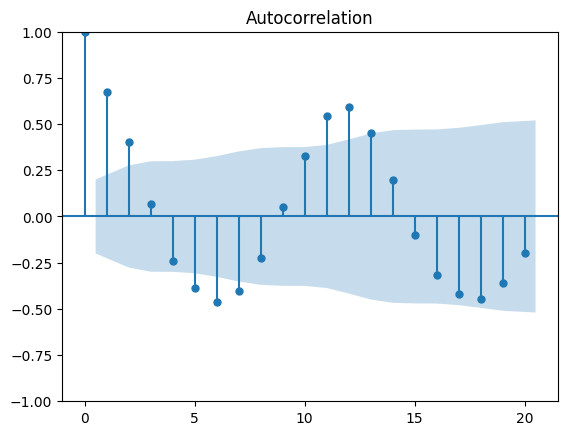

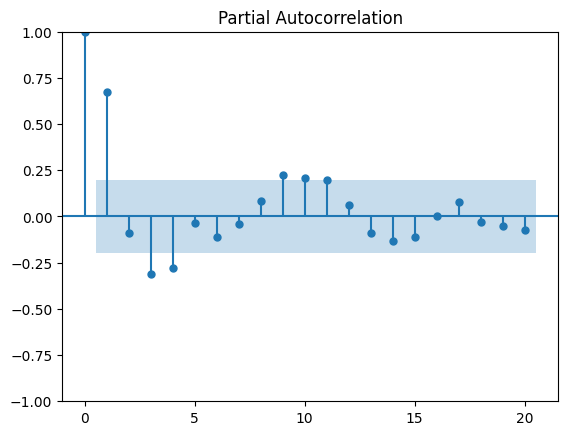

In [20]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [21]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,bruehler_straße,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,8304,1.000000,0.000000,NaN,1,8.318925,-8.318925
2016-02-01,2016-02-01,14704,8099.552022,8.999564,8.999564,2,9.502807,-0.503243
2016-03-01,2016-03-01,16553,10439.274317,9.253330,0.253766,3,9.849263,-0.595933
2016-04-01,2016-04-01,25046,21186.305929,9.961110,0.707780,4,10.030930,-0.069820
2016-05-01,2016-05-01,26992,23648.771903,10.071066,0.109956,5,10.221226,-0.150159
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,29346,26627.520569,10.189701,0.075027,8,10.250489,-0.060789
2023-09-01,2023-09-01,29189,26428.852965,10.182212,-0.007489,9,10.235070,-0.052858
2023-10-01,2023-10-01,31000,28720.490107,10.265366,0.083154,10,10.085189,0.180177


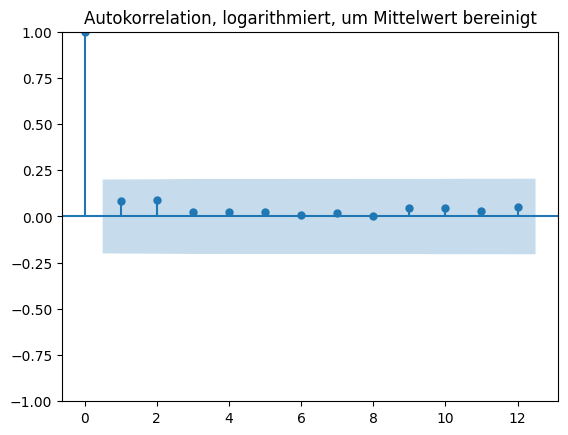

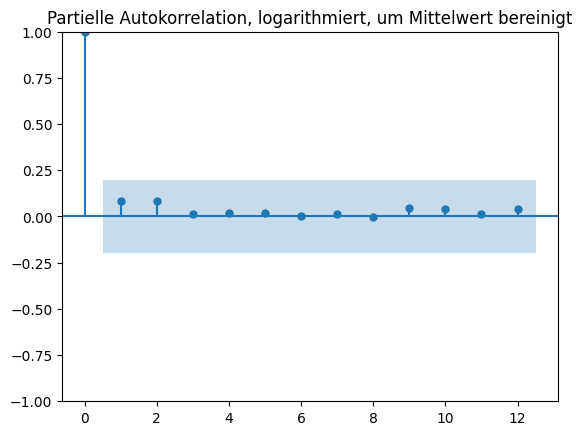

In [22]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

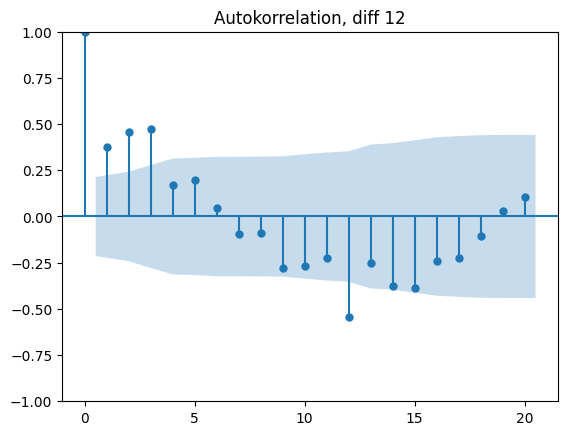

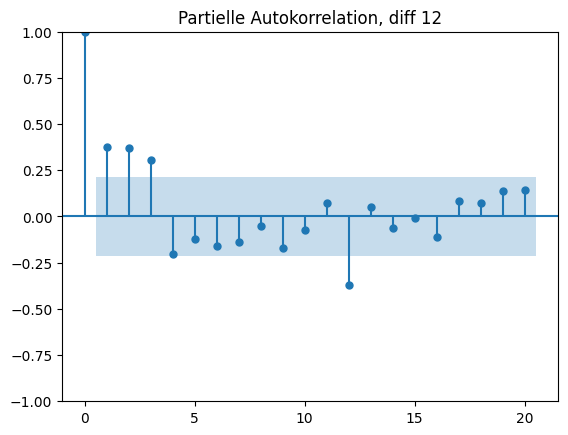

In [23]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [31]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()
result9 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(3, 1, 0, seasonal)).fit()
result10 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 3, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))
print('ARIMA (0,1,1)x(3,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result9.llf, result9.aic))
print('ARIMA (0,1,1)x(0,1,3,12) LL {:.4f}, AIC: {:.4f}'.format(result10.llf, result10.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -110.5962, AIC: 223.1923
ARIMA (0,1,0)x(0,1,0,12) LL -110.2868, AIC: 222.5735
ARIMA (1,0,0)x(0,1,1,12) LL -110.0851, AIC: 226.1703
ARIMA (1,0,0)x(0,1,2,12) LL -110.0745, AIC: 228.1490
ARIMA (1,1,0)x(0,1,2,12) LL -105.5805, AIC: 219.1609
ARIMA (0,0,1)x(0,1,2,12) LL -110.1500, AIC: 228.3000
ARIMA (0,1,1)x(0,1,2,12) LL -108.2117, AIC: 222.4233
ARIMA (0,1,1)x(2,1,0,12) LL -108.1071, AIC: 224.2142
ARIMA (0,1,1)x(3,1,0,12) LL -108.0133, AIC: 226.0267
ARIMA (0,1,1)x(0,1,3,12) LL -107.9414, AIC: 225.8828


In [40]:
print(result3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -110.085
Date:                              Mon, 10 Feb 2025   AIC                            226.170
Time:                                      23:02:50   BIC                            233.123
Sample:                                  01-01-2016   HQIC                           228.946
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1730      0.083      2.074      0.038       0.010       0.337
ma.S.L12       0.22

In [38]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

            predicted_mean      unlogged   new_predict
2023-04-01       10.486786  35838.793464  36625.344057
2023-05-01       10.663197  42753.103531  42089.479412
2023-06-01       10.705260  44589.783405  43540.942730
2023-07-01       10.286503  29334.001591  31484.836485
2023-08-01       10.930507  55854.592540  52443.124043
2023-09-01       10.343854  31065.539655  32853.209940
2023-10-01       10.502325  36400.035179  37068.873587
2023-11-01       10.320644  30352.808500  32289.963649
2023-12-01        9.490175  13229.112968  18757.711080
2024-01-01        9.785975  17782.581451  22356.156606
2024-02-01       10.132204  25139.710913  28170.236509
2024-03-01       10.201426  26941.572933  29594.184506
2024-04-01       10.695461  44154.962418  43197.319042
2024-05-01       10.668422  42977.070256  42266.472415
2024-06-01       10.884094  53321.430242  50441.255232
2024-07-01       10.317191  30248.185255  32207.283588
2024-08-01       11.087612  65356.458872  59952.113843
2024-09-01

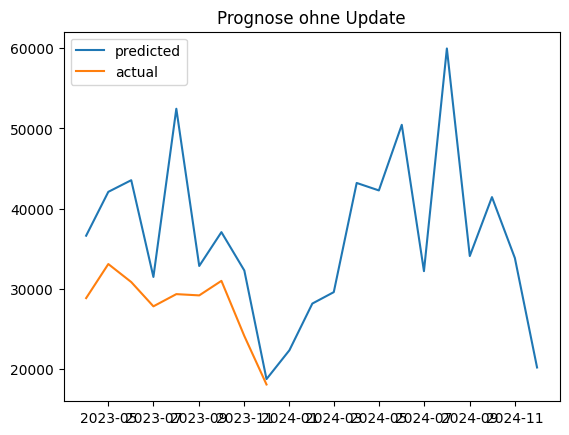

mean absolute error (mae): ARIMA: 8308.9428
mean squared error (mse): ARIMA: 107398367.7726
mean absolute percentage error (mape): ARIMA: 0.2853


In [39]:
plt.plot(y_pred_no_update['new_predict'], label='predicted')
plt.plot(df_test_seas[header], label='actual')

plt.title('Prognose ohne Update')
plt.legend()
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [41]:
arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.112153,24640.651300,27775.847301
2023-05-01,10.732665,45828.681097,44519.999877
2023-06-01,10.354757,31406.094050,33122.338066
2023-07-01,10.301095,29765.203046,31825.599785
2023-08-01,10.648504,42129.511059,41596.676277
2023-09-01,10.280910,29170.393447,31355.542740
2023-10-01,10.270616,28871.667082,31119.469831
2023-11-01,10.285892,29316.099520,31470.689110
2023-12-01,9.298134,10917.627186,16931.025400
2024-01-01,9.777526,17632.972045,22237.925569


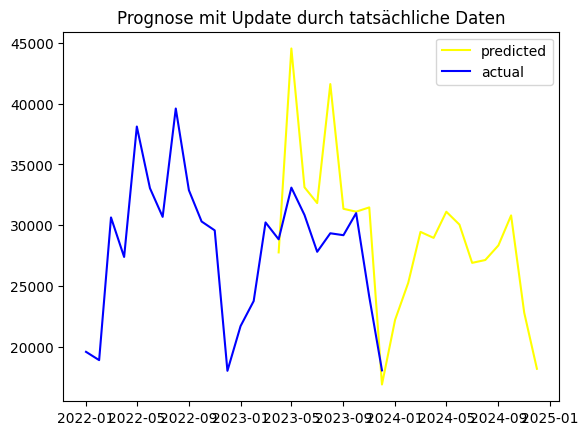

In [42]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [43]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 4645.3826
mean squared error (mse): ARIMA: 40321271.0813
mean absolute percentage error (mape): ARIMA: 0.1626
